In [ ]:
! pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

In [ ]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets download -d gamersclub/brazilian-csgo-plataform-dataset-by-gamers-club

In [ ]:
import shutil
shutil.unpack_archive("/content/brazilian-csgo-plataform-dataset-by-gamers-club.zip",
                      "/content/brazilian-csgo-plataform-dataset-by-gamers-club")

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
df=pd.read_csv("/content/brazilian-csgo-plataform-dataset-by-gamers-club/tb_lobby_stats_player.csv")
df.head()

,idLobbyGame,idPlayer,idRoom,qtKill,qtAssist,qtDeath,qtHs,qtBombeDefuse,qtBombePlant,qtTk,...,qtFlashAssist,qtHitHeadshot,qtHitChest,qtHitStomach,qtHitLeftAtm,qtHitRightArm,qtHitLeftLeg,qtHitRightLeg,flWinner,dtCreatedAt
0,1,1,1,5,1,16,2,0,0,0.0,...,0.0,3.0,13.0,4.0,2.0,2.0,1.0,0.0,0,2022-01-21 19:45:44
1,2,1,2,24,3,18,6,0,4,0.0,...,0.0,7.0,26.0,14.0,2.0,1.0,1.0,3.0,1,2022-02-04 02:09:47
2,3,2,3,6,4,23,2,0,1,0.0,...,0.0,3.0,15.0,8.0,1.0,2.0,0.0,2.0,0,2021-09-18 18:07:43
3,3,391,27508,10,5,20,4,1,0,0.0,...,0.0,6.0,27.0,10.0,1.0,7.0,6.0,6.0,1,2021-09-18 18:07:43
4,4,2,4,8,4,26,6,0,2,0.0,...,2.0,8.0,19.0,12.0,2.0,3.0,2.0,5.0,0,2021-09-27 00:17:45


In [ ]:
len(df)

184152

Text(0.5, 1.0, 'Missing values heatmap')

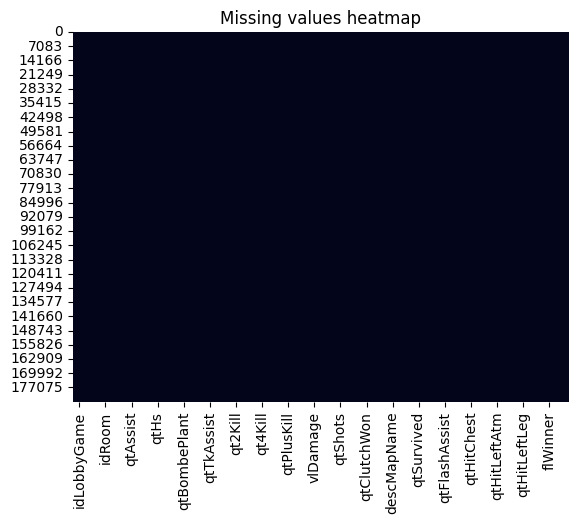

In [ ]:
import seaborn as sns
df.isnull().sum()
sns.heatmap(df.isnull(), cbar = False).set_title("Missing values heatmap")

In [ ]:
def replace_random_with_nan(df, column_name, percentage=0.1):

    df_copy = df.copy()


    num_rows = int(len(df) * percentage)


    random_indices = df_copy.sample(num_rows).index


    df_copy.loc[random_indices, column_name] = np.nan

    return df_copy

In [ ]:
df.columns

Index(['idLobbyGame', 'idPlayer', 'idRoom', 'qtKill', 'qtAssist', 'qtDeath',
       'qtHs', 'qtBombeDefuse', 'qtBombePlant', 'qtTk', 'qtTkAssist',
       'qt1Kill', 'qt2Kill', 'qt3Kill', 'qt4Kill', 'qt5Kill', 'qtPlusKill',
       'qtFirstKill', 'vlDamage', 'qtHits', 'qtShots', 'qtLastAlive',
       'qtClutchWon', 'qtRoundsPlayed', 'descMapName', 'vlLevel', 'qtSurvived',
       'qtTrade', 'qtFlashAssist', 'qtHitHeadshot', 'qtHitChest',
       'qtHitStomach', 'qtHitLeftAtm', 'qtHitRightArm', 'qtHitLeftLeg',
       'qtHitRightLeg', 'flWinner', 'dtCreatedAt'],
      dtype='object')

In [ ]:
df2 = replace_random_with_nan(df, "flWinner")

In [ ]:
df2 = replace_random_with_nan(df2, "qtHitStomach")

Text(0.5, 1.0, 'Missing values heatmap')

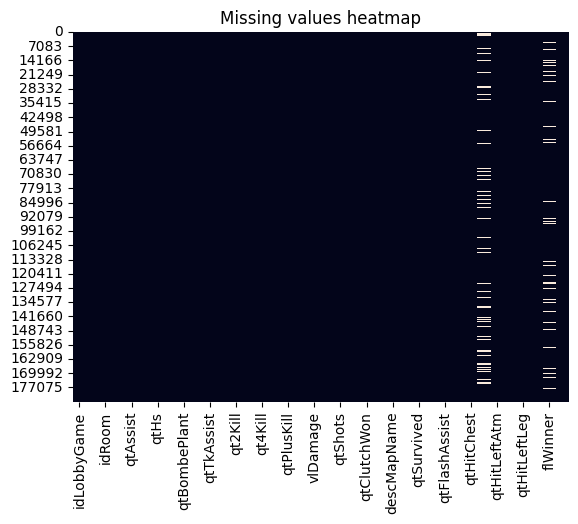

In [ ]:
df2.isnull().sum()
sns.heatmap(df2.isnull(), cbar = False).set_title("Missing values heatmap")

In [ ]:
df2["flWinner"].value_counts()

,count
flWinner,
0.0,83808
1.0,81929


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184152 entries, 0 to 184151
Data columns (total 38 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   idLobbyGame     184152 non-null  int64  
 1   idPlayer        184152 non-null  int64  
 2   idRoom          184152 non-null  int64  
 3   qtKill          184152 non-null  int64  
 4   qtAssist        184152 non-null  int64  
 5   qtDeath         184152 non-null  int64  
 6   qtHs            184152 non-null  int64  
 7   qtBombeDefuse   184152 non-null  int64  
 8   qtBombePlant    184152 non-null  int64  
 9   qtTk            184032 non-null  float64
 10  qtTkAssist      184032 non-null  float64
 11  qt1Kill         184152 non-null  int64  
 12  qt2Kill         184152 non-null  int64  
 13  qt3Kill         184152 non-null  int64  
 14  qt4Kill         184152 non-null  int64  
 15  qt5Kill         184152 non-null  int64  
 16  qtPlusKill      184152 non-null  int64  
 17  qtFirstKil

In [ ]:
df2 = df2.dropna(subset=['flWinner'])

In [ ]:
df2['dtCreatedAt'] = pd.to_datetime(df2['dtCreatedAt'])

df2['year'] = df2['dtCreatedAt'].dt.year
df2['month'] = df2['dtCreatedAt'].dt.month
df2['day'] = df2['dtCreatedAt'].dt.day
df2['dayofweek'] = df2['dtCreatedAt'].dt.dayofweek
df2['hour'] = df2['dtCreatedAt'].dt.hour
df2['quarter'] = df2['dtCreatedAt'].dt.quarter

In [ ]:
df2["descMapName"].value_counts()

,count
descMapName,
de_mirage,52390
de_inferno,37848
de_dust2,21395
de_vertigo,17939
de_nuke,12657
de_overpass,12635
de_train,7053
de_ancient,3820


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df2['descMapName'] = le.fit_transform(df2['descMapName'])
df2["descMapName"].value_counts()

,count
descMapName,
3,52390
2,37848
1,21395
7,17939
4,12657
5,12635
6,7053
0,3820


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 165737 entries, 0 to 184151
Data columns (total 43 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   idLobbyGame     165737 non-null  int64  
 1   idPlayer        165737 non-null  int64  
 2   idRoom          165737 non-null  int64  
 3   qtKill          165737 non-null  int64  
 4   qtAssist        165737 non-null  int64  
 5   qtDeath         165737 non-null  int64  
 6   qtHs            165737 non-null  int64  
 7   qtBombeDefuse   165737 non-null  int64  
 8   qtBombePlant    165737 non-null  int64  
 9   qtTk            165629 non-null  float64
 10  qtTkAssist      165629 non-null  float64
 11  qt1Kill         165737 non-null  int64  
 12  qt2Kill         165737 non-null  int64  
 13  qt3Kill         165737 non-null  int64  
 14  qt4Kill         165737 non-null  int64  
 15  qt5Kill         165737 non-null  int64  
 16  qtPlusKill      165737 non-null  int64  
 17  qtFirstKill    

In [ ]:
df2=df2.drop(["dtCreatedAt"], axis=1)


In [ ]:
from sklearn.model_selection import train_test_split
df3, _ = train_test_split(df2, test_size=0.9, stratify=df2['flWinner'])

In [ ]:
df3["flWinner"].value_counts()

,count
flWinner,
0.0,8380
1.0,8193


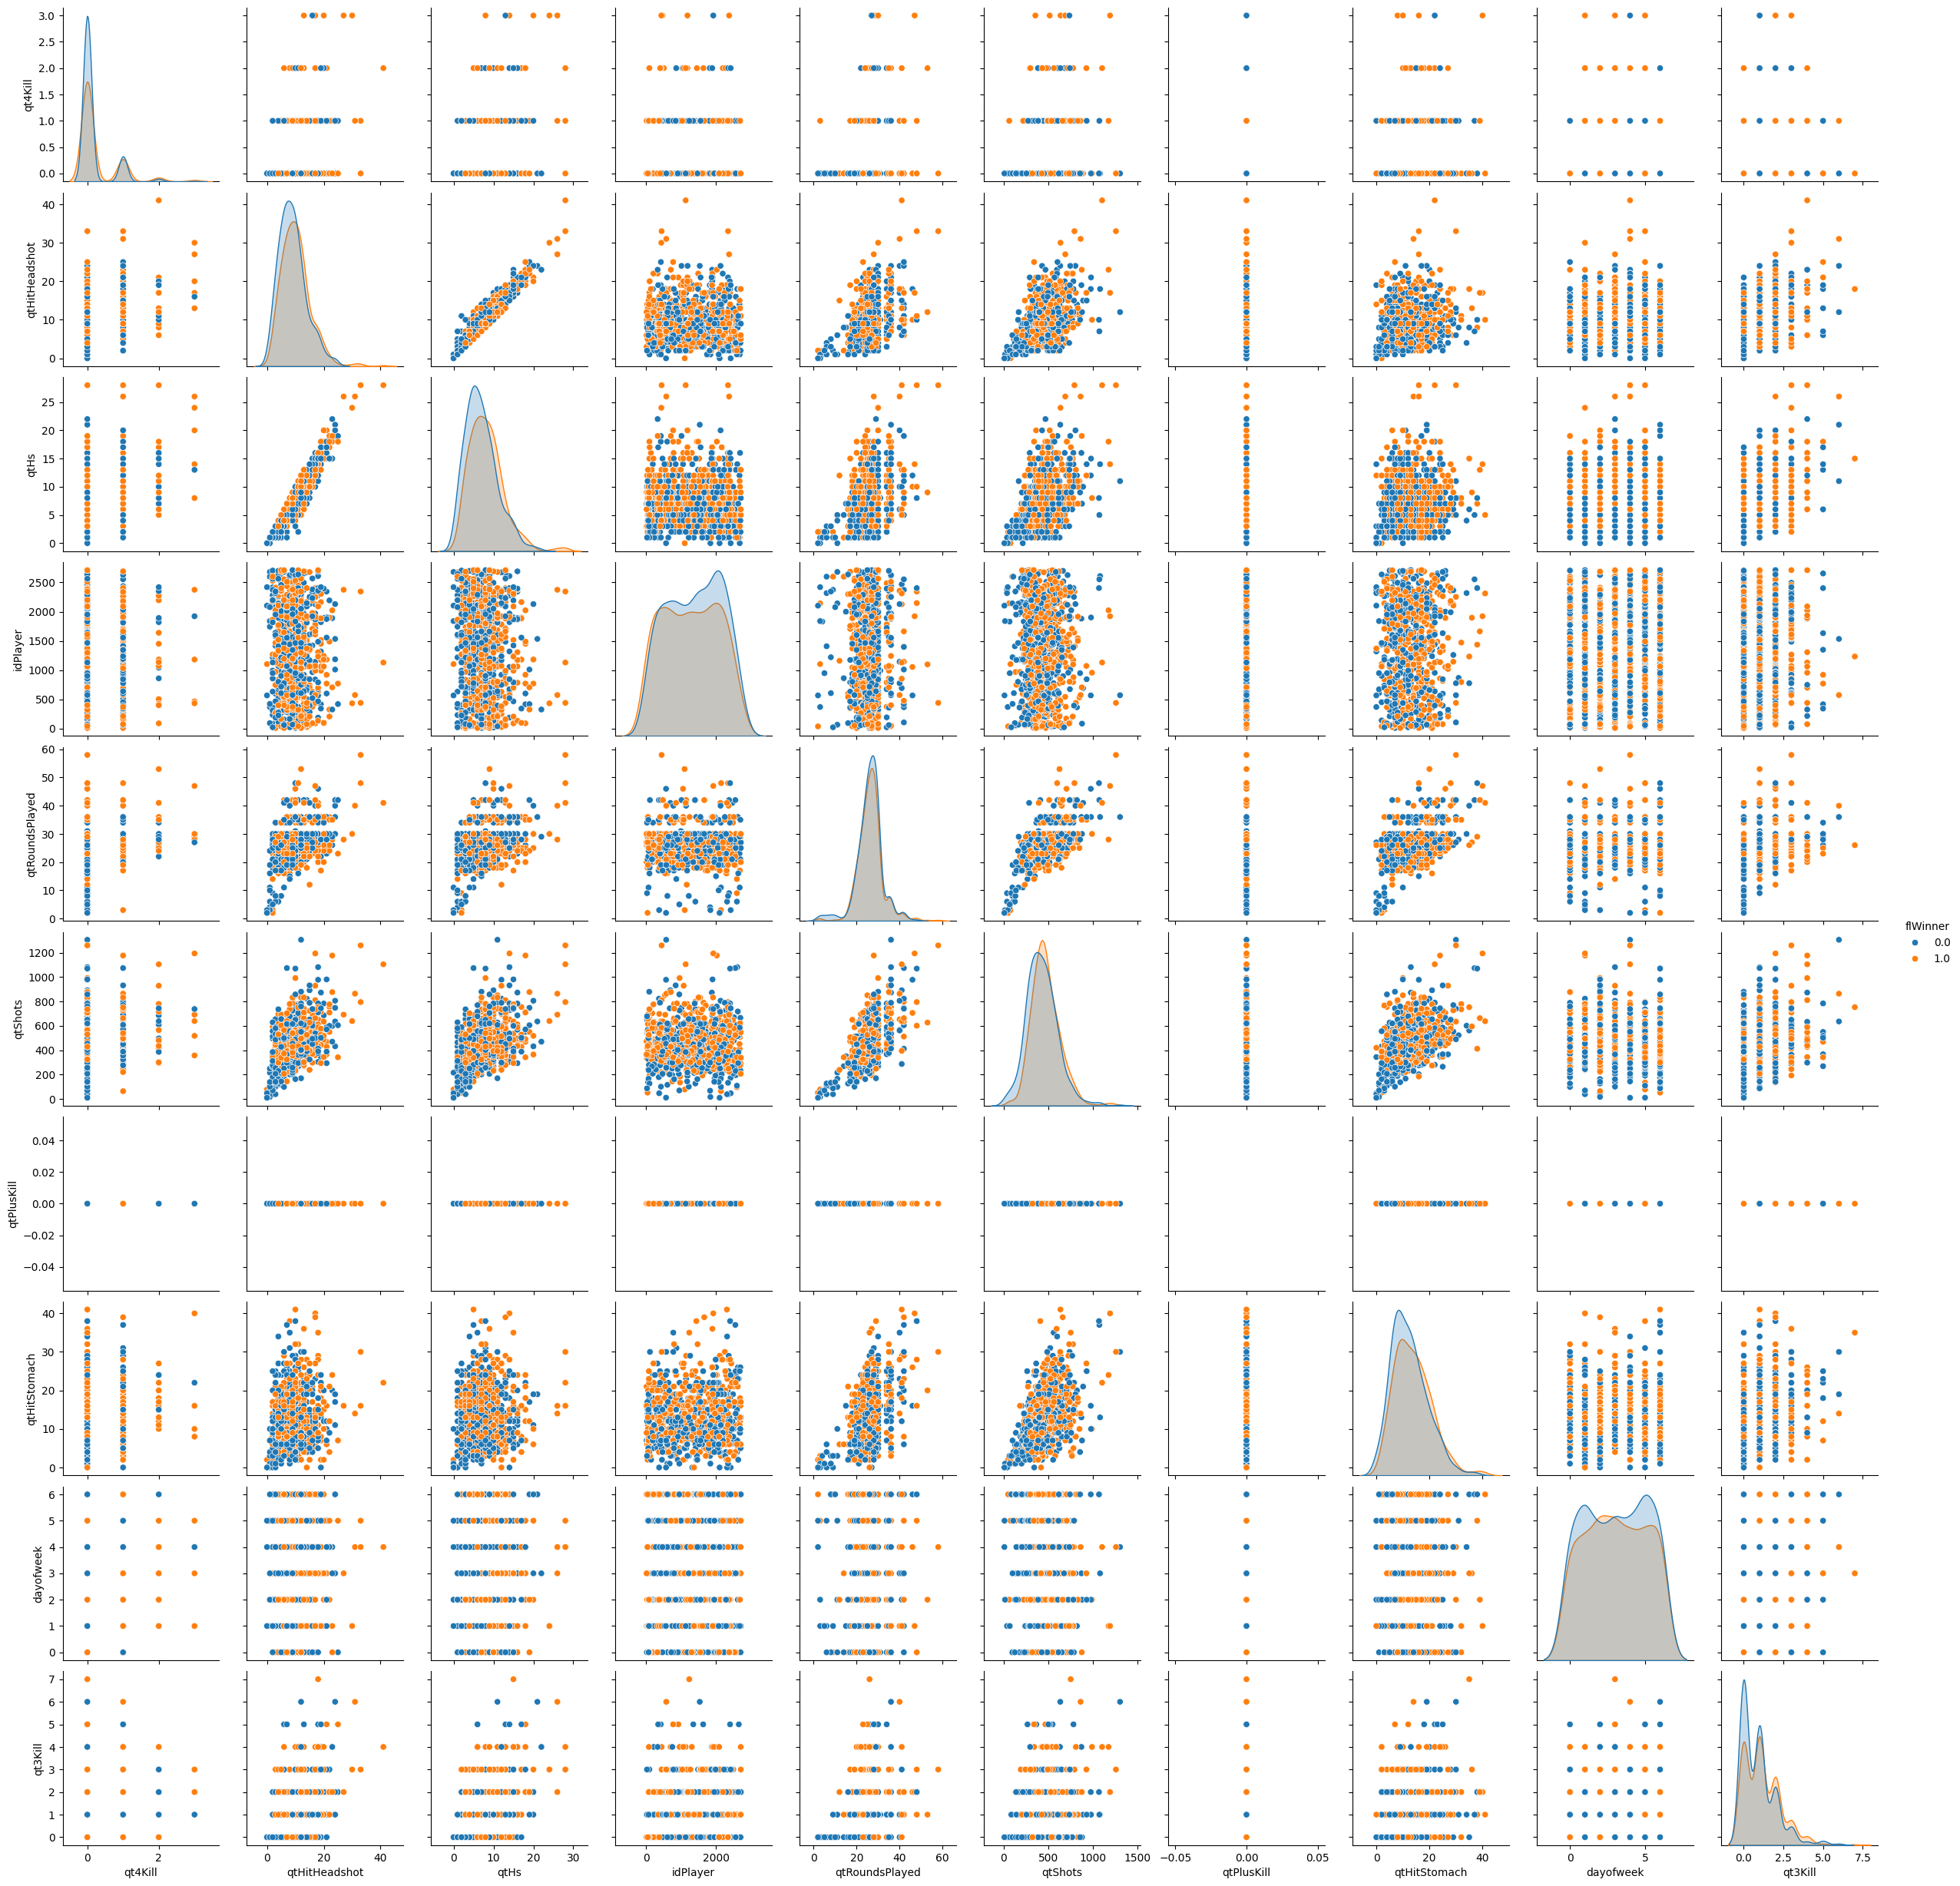

In [ ]:
df_sample = df3.sample(n=1000, random_state=42)
target_column = 'flWinner'


random_columns = df_sample.drop(columns=[target_column]).sample(n=10, axis=1).columns


columns_for_plot = list(random_columns) + [target_column]


df_random = df_sample[columns_for_plot]


sns.pairplot(df_random, hue=target_column)
plt.show()

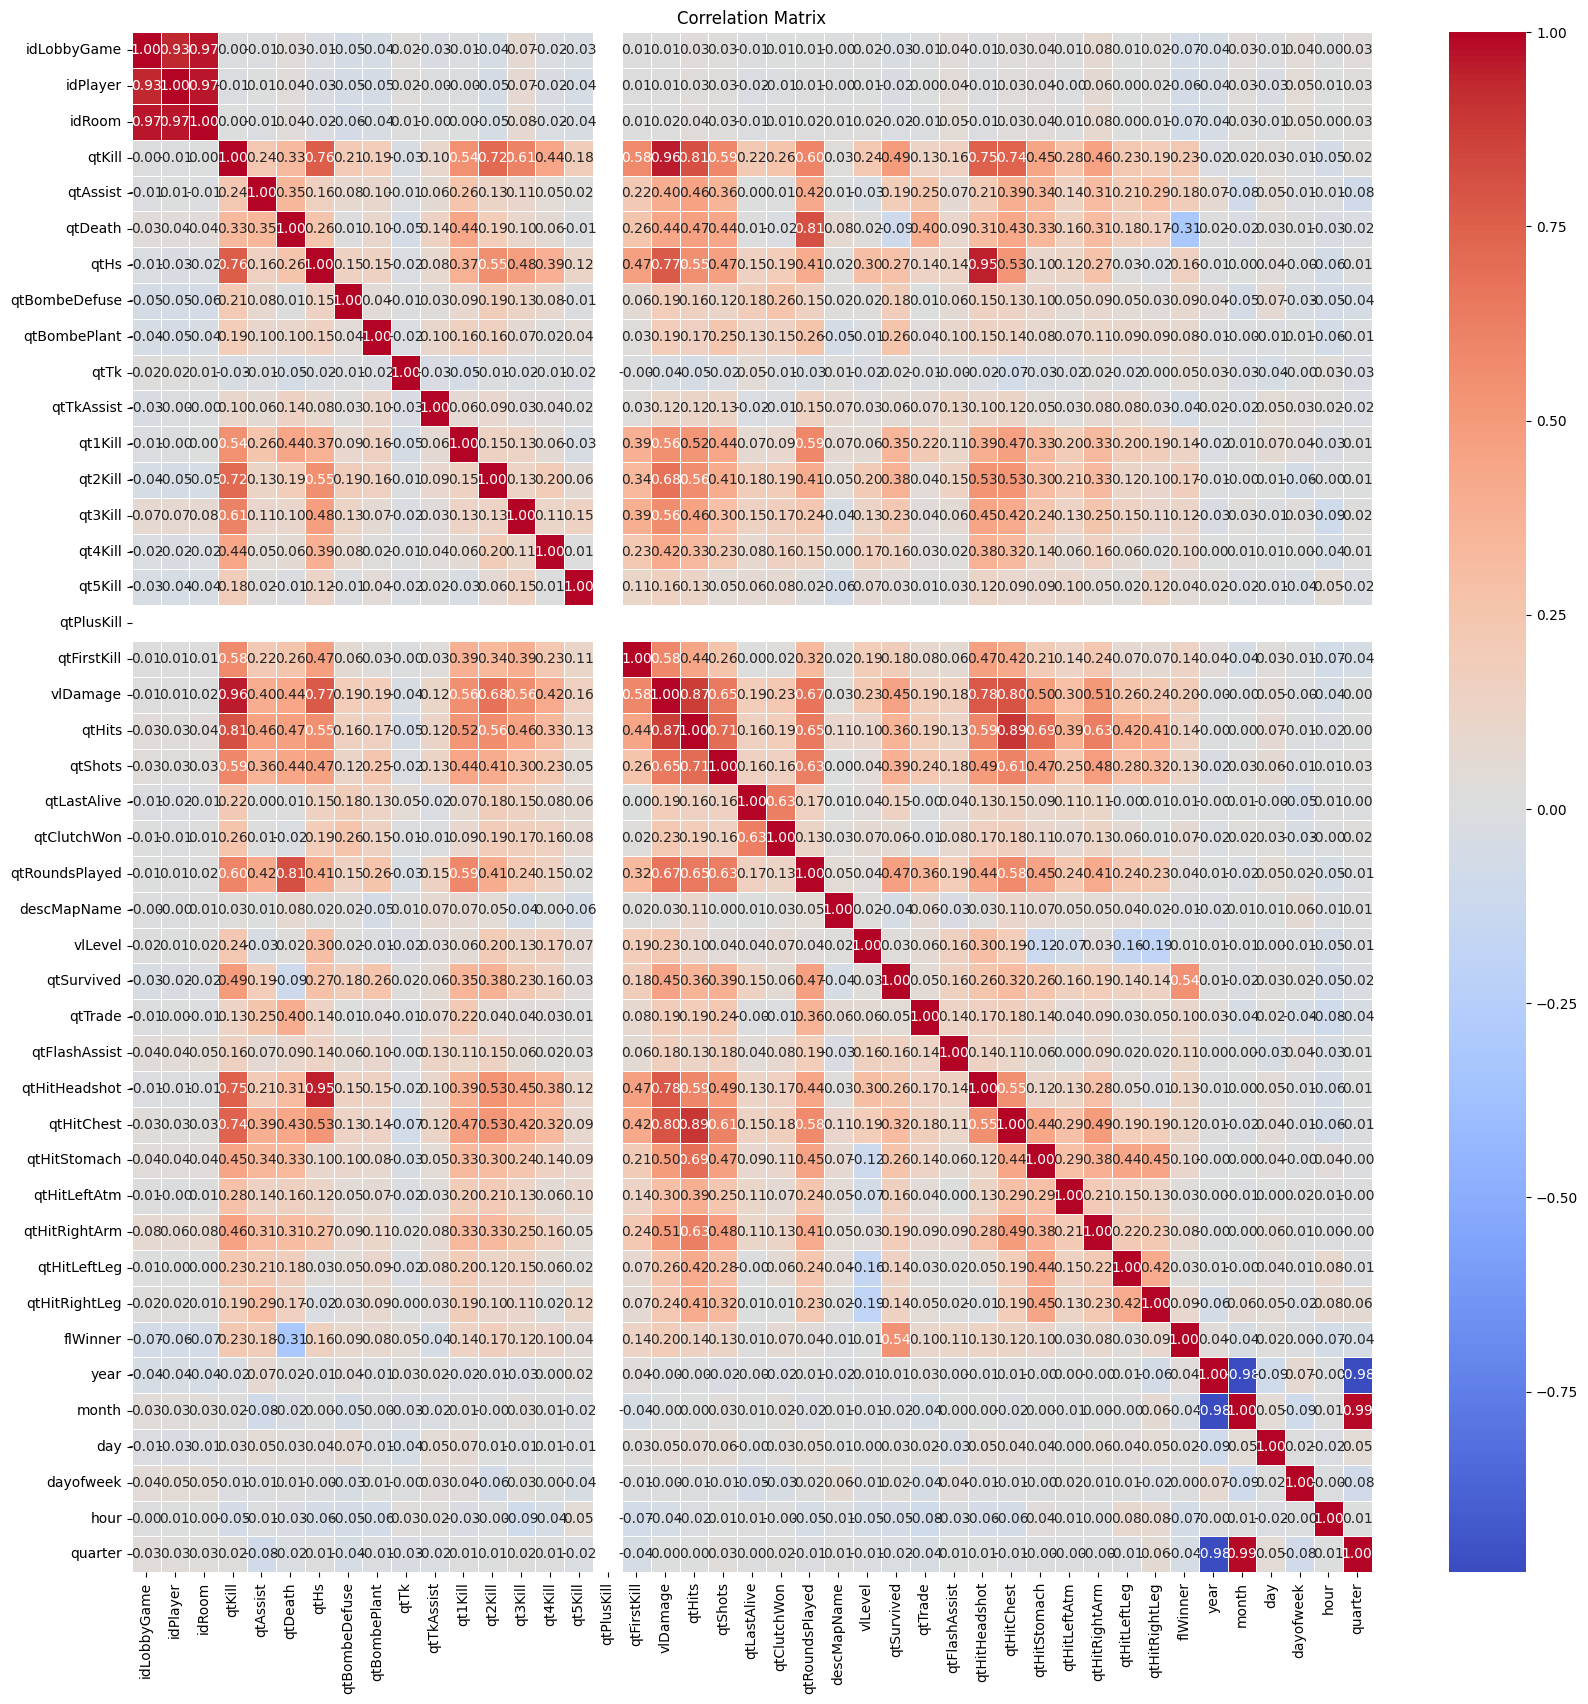

In [ ]:
df_sample = df3.sample(n=1000, random_state=42)


correlation_matrix = df_sample.corr()


plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df3 = df3.fillna(df3.median())

In [ ]:
df3 = df3.drop(['qtTk','day', 'year', 'month', 'qtPlusKill'], axis=1)

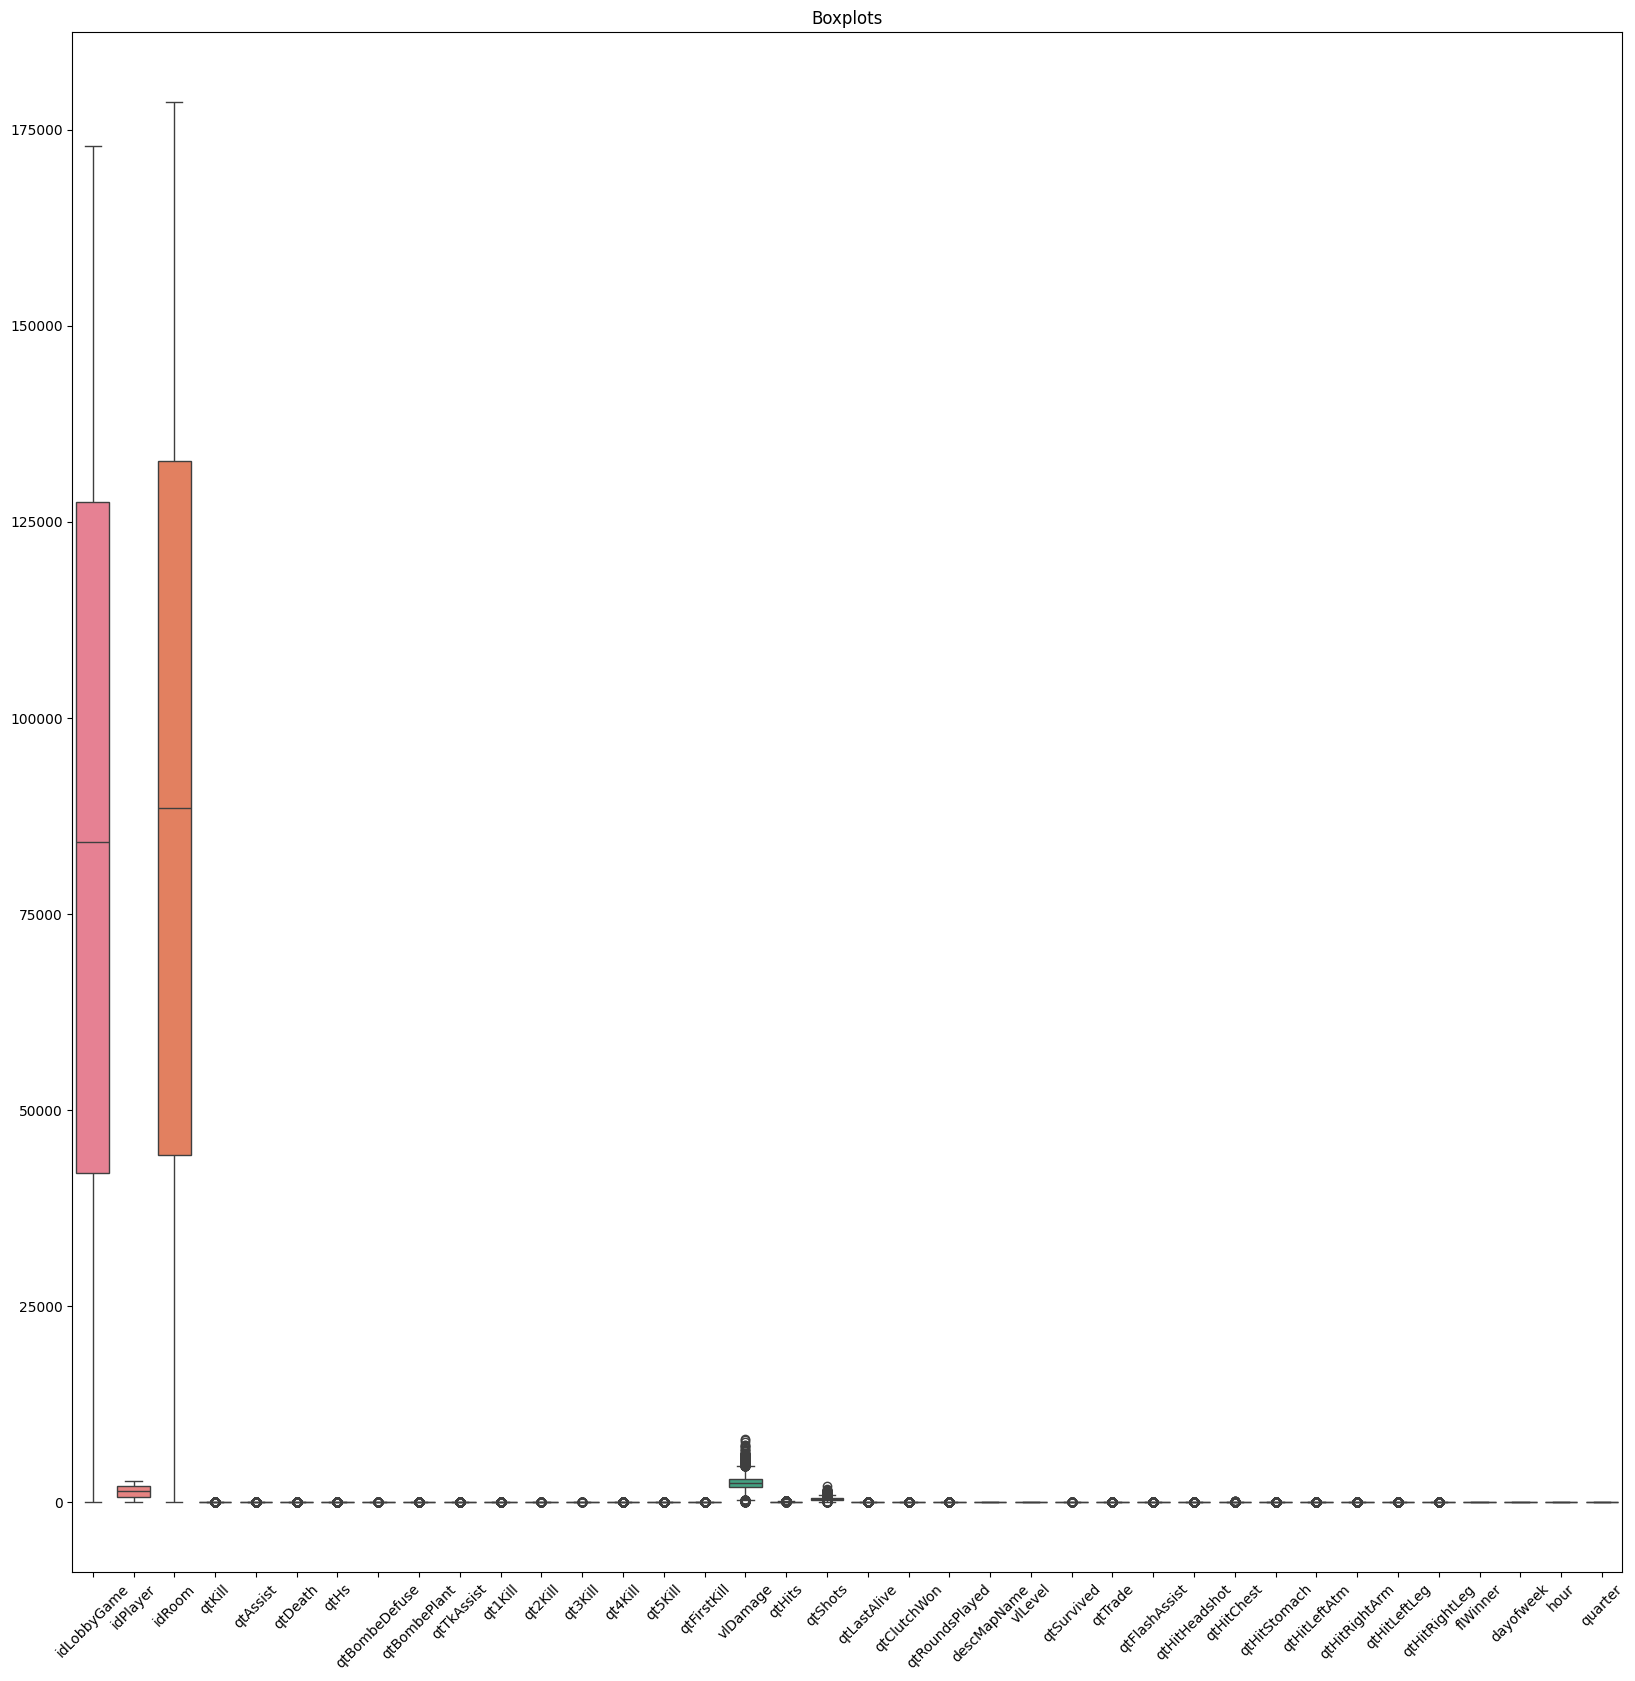

In [ ]:
numeric_columns = df3.select_dtypes(include=['number']).columns


plt.figure(figsize=(20, 20))
sns.boxplot(data=df3[numeric_columns])
plt.title('Boxplots')
plt.xticks(rotation=45)
plt.show()

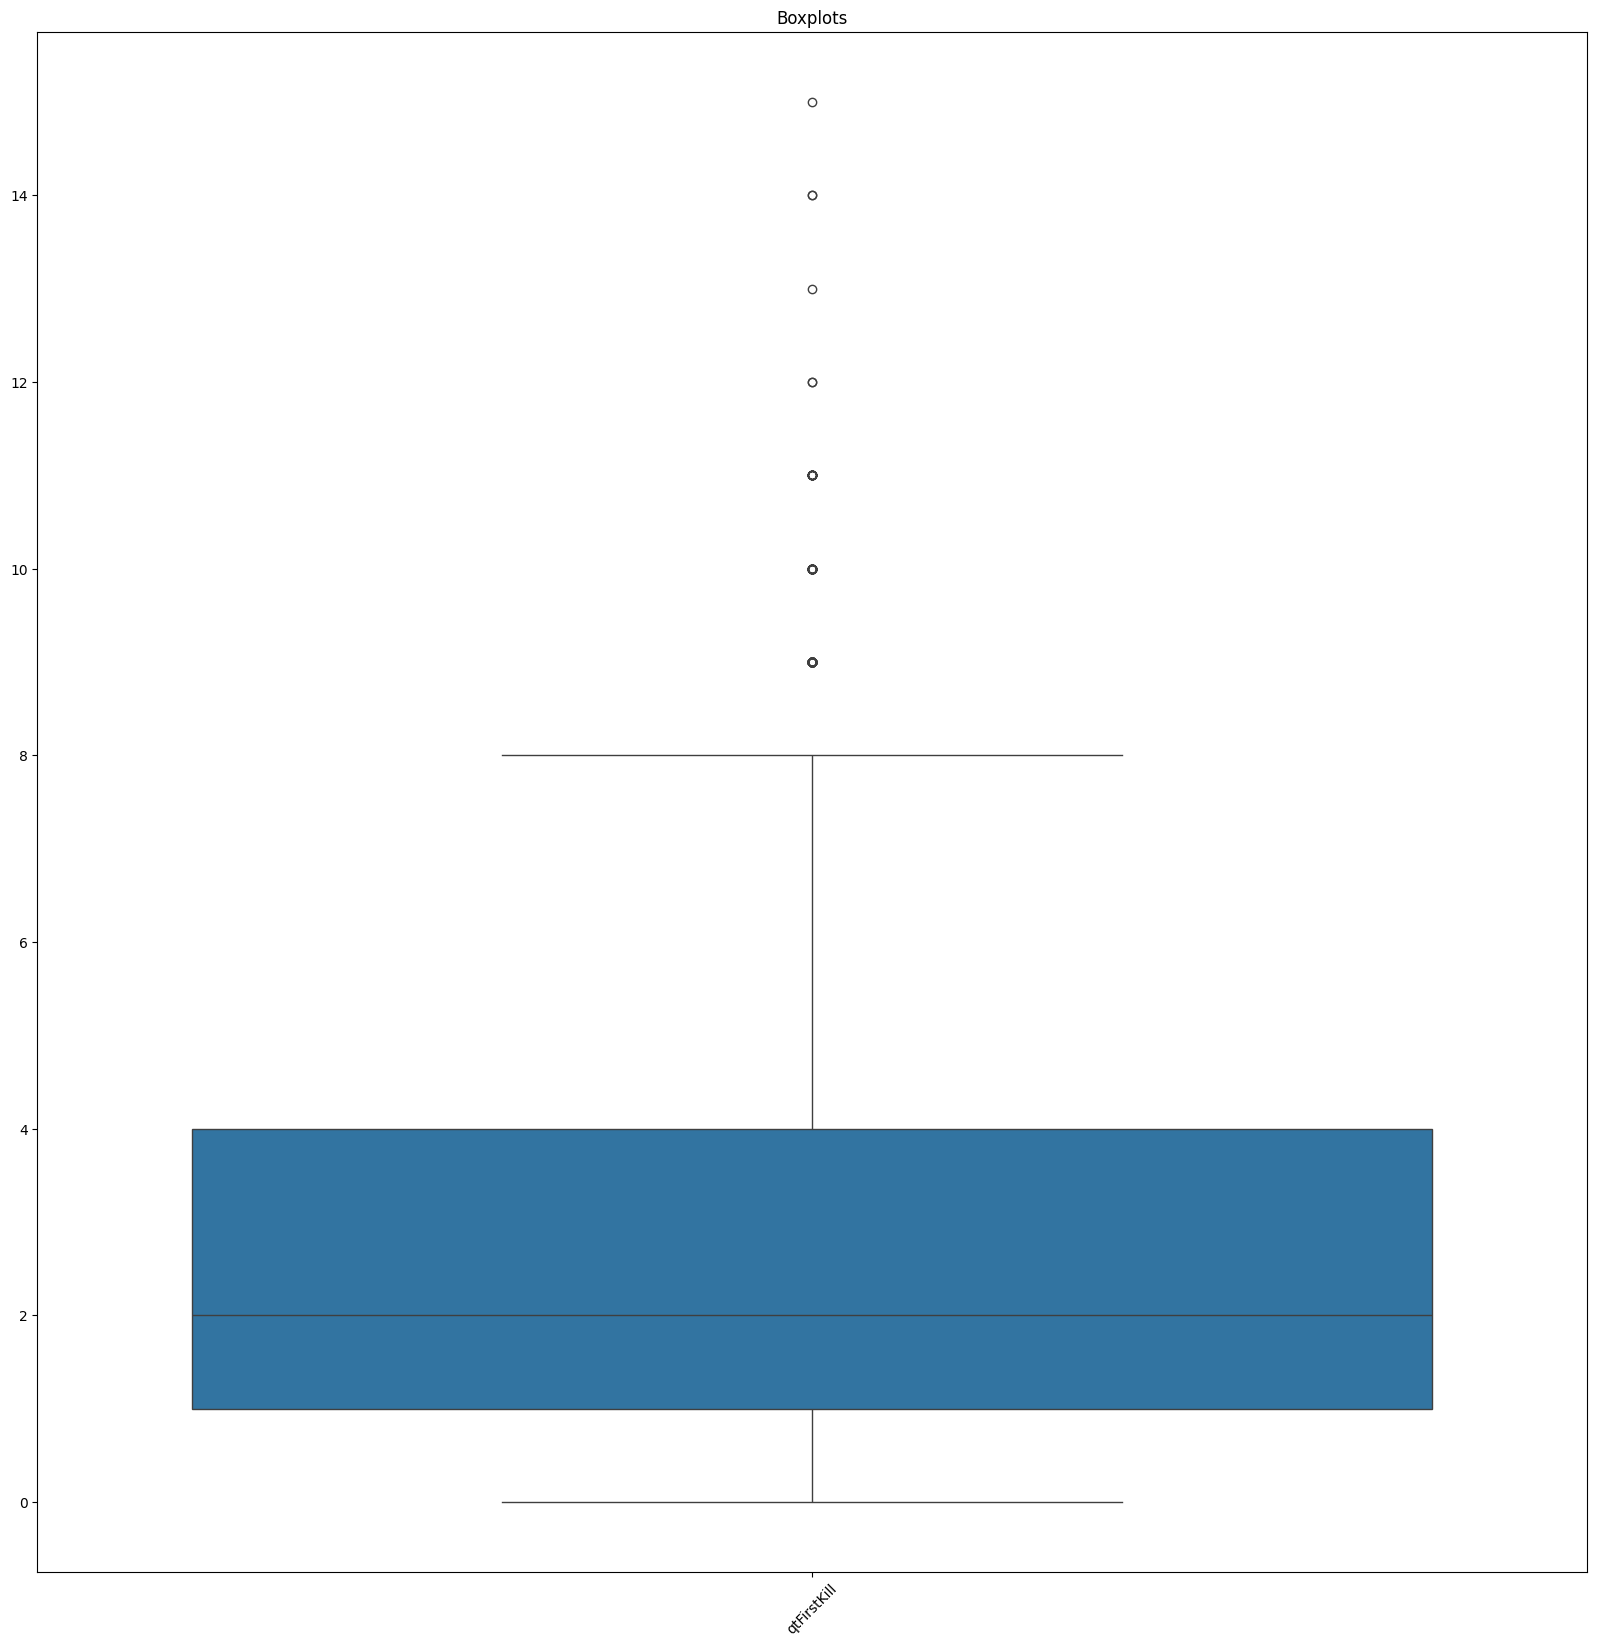

In [ ]:



plt.figure(figsize=(20, 20))
sns.boxplot(data=df3[['qtFirstKill']])
plt.title('Boxplots')
plt.xticks(rotation=45)
plt.show()

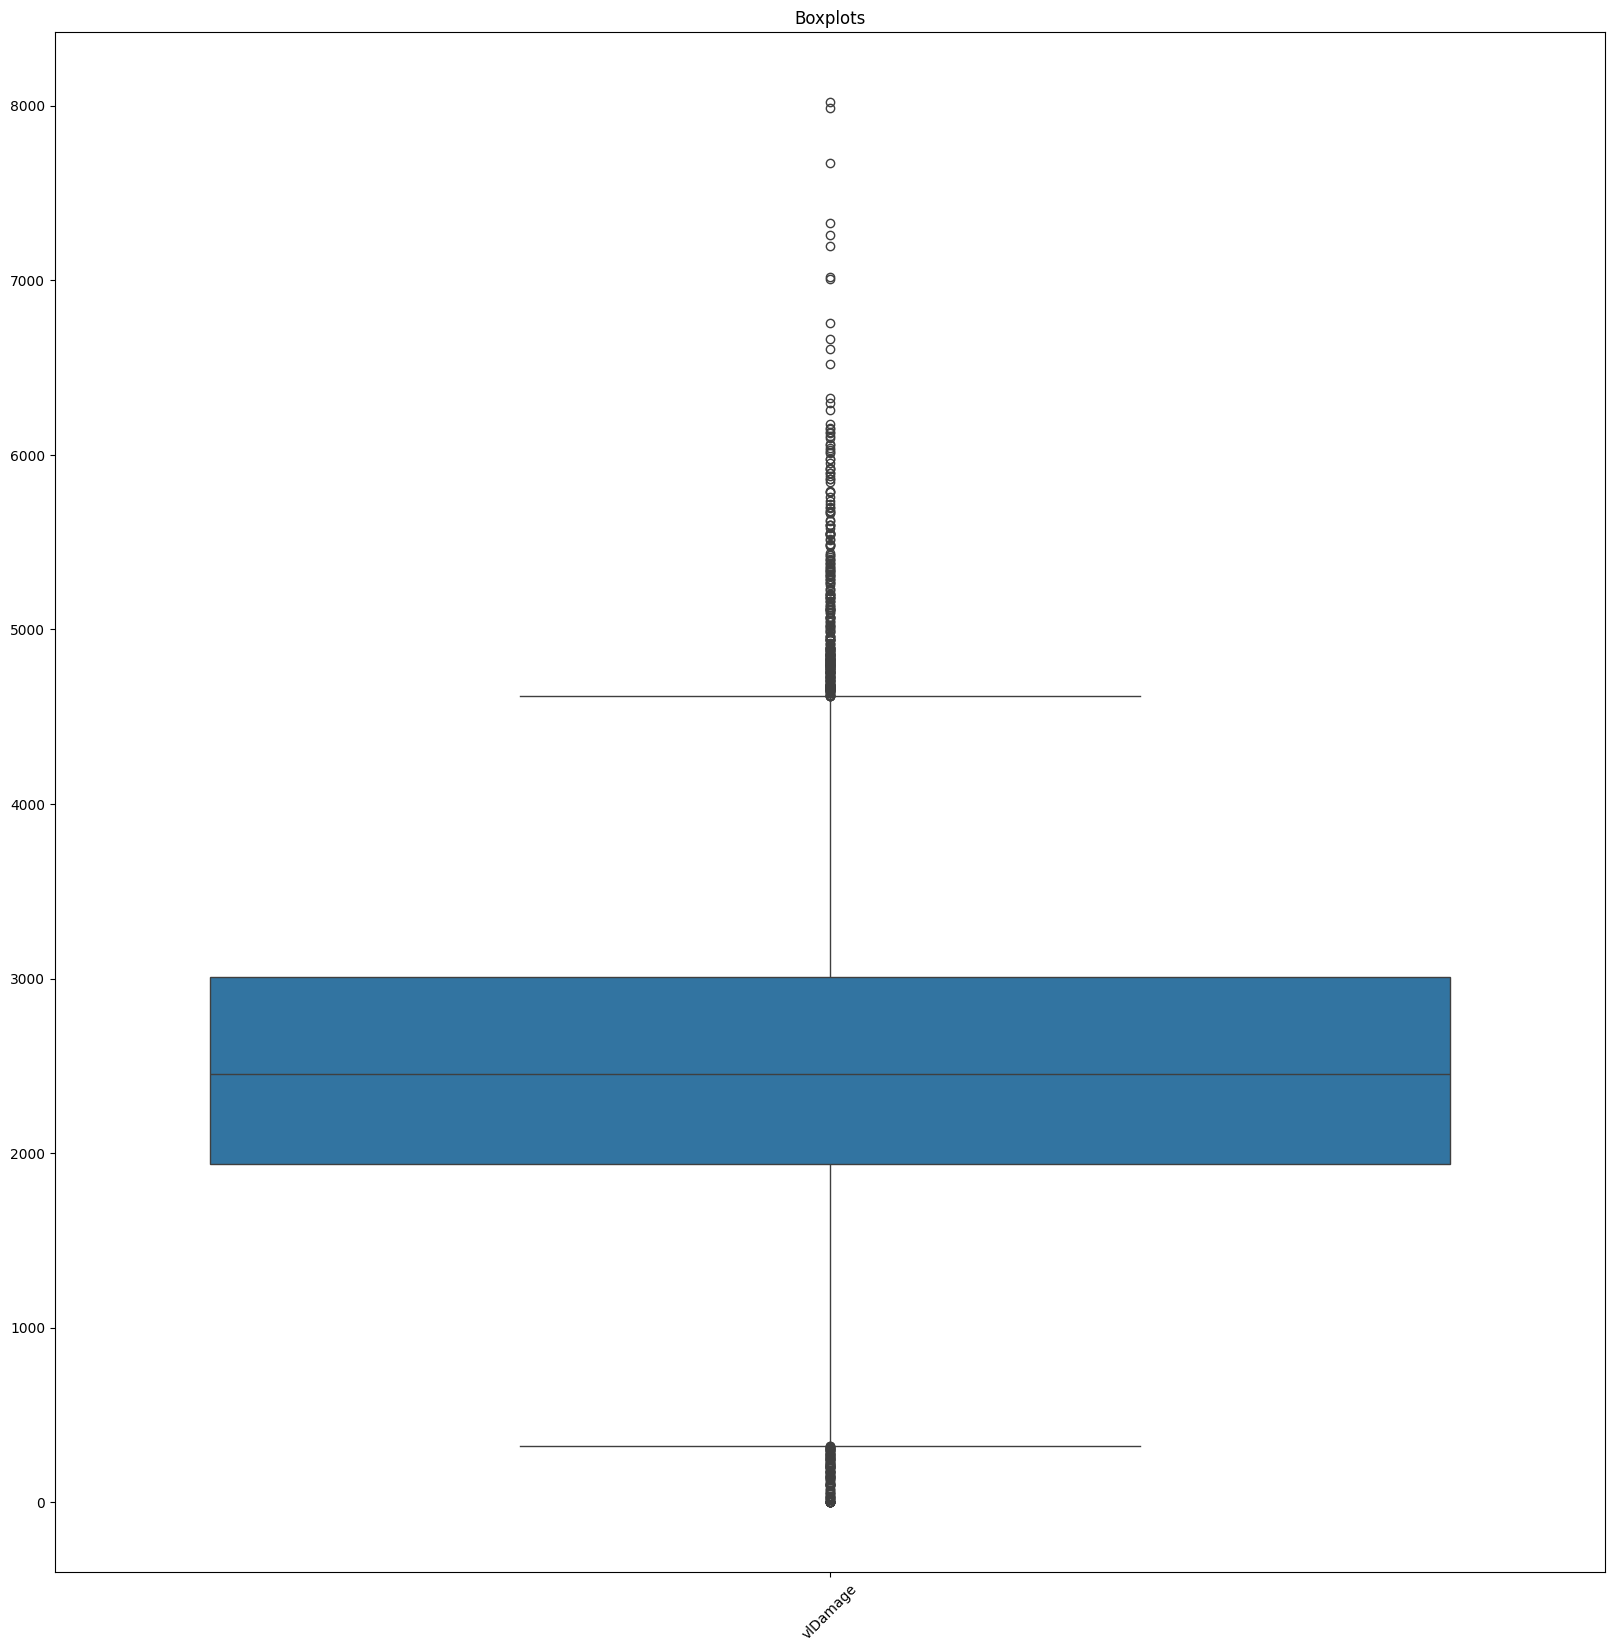

In [ ]:

plt.figure(figsize=(20, 20))
sns.boxplot(data=df3[['vlDamage']])
plt.title('Boxplots')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df3 = df3[df3['vlDamage'] <= 6500]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df3 = pd.DataFrame(scaler.fit_transform(df3), columns=df3.columns)

In [ ]:
x = df3.drop(['flWinner'], axis=1)
y = df3['flWinner']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)


KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(x_test)
y_pred_proba = knn.predict_proba(x_test)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'Accuracy: {accuracy:.2f}')
print(f'ROC AUC Score: {roc_auc:.2f}')

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.78
ROC AUC Score: 0.88

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.81      0.79      1695
         1.0       0.79      0.75      0.77      1618

    accuracy                           0.78      3313
   macro avg       0.78      0.78      0.78      3313
weighted avg       0.78      0.78      0.78      3313



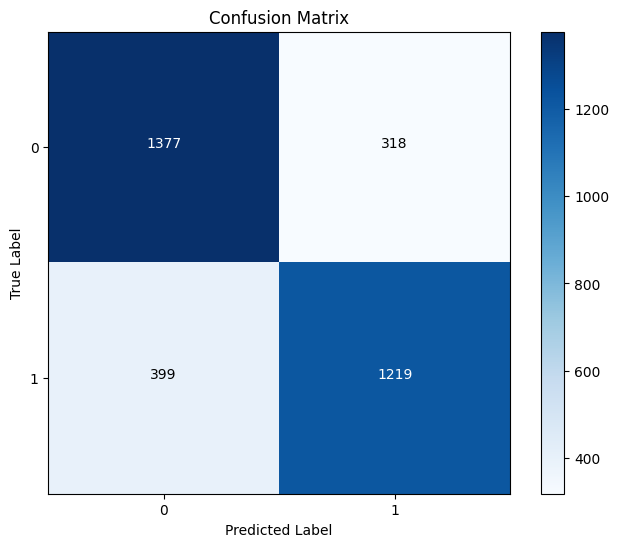

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
import itertools
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = range(len(conf_matrix))
plt.xticks(tick_marks, [0, 1])
plt.yticks(tick_marks, [0, 1])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)


thresh = conf_matrix.max() / 2.
for i, j in itertools.product(range(conf_matrix.shape[0]), range(conf_matrix.shape[1])):
    plt.text(j, i, format(conf_matrix[i, j], 'd'),
             horizontalalignment="center",
             color="white" if conf_matrix[i, j] > thresh else "black")

plt.show()

<Figure size 800x600 with 0 Axes>

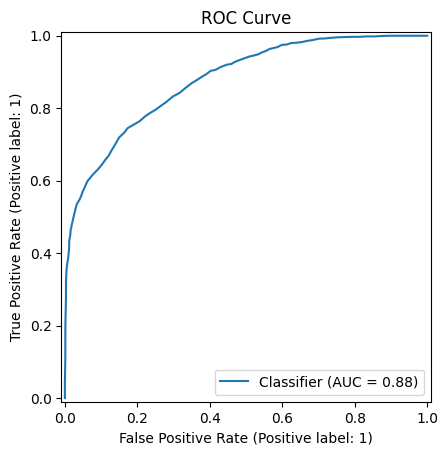

In [ ]:
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title('ROC Curve')
plt.show()

In [ ]:
from sklearn.svm import SVC
svm = SVC(probability=True)
svm.fit(x_train, y_train)

SVC(probability=True)

In [ ]:
y_pred = svm.predict(x_test)
y_pred_proba = svm.predict_proba(x_test)[:, 1]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = rf_model.predict(x_test)
y_pred_proba = rf_model.predict_proba(x_test)[:, 1]

Feature importances:
           Feature  Importance
24      qtSurvived    0.179292
5          qtDeath    0.145091
21  qtRoundsPlayed    0.044971
3           qtKill    0.040239
16        vlDamage    0.039351
18         qtShots    0.035711
4         qtAssist    0.030676
17          qtHits    0.028491
25         qtTrade    0.025965
0      idLobbyGame    0.025911
2           idRoom    0.025732
28      qtHitChest    0.025388
1         idPlayer    0.024806
29    qtHitStomach    0.022654
10         qt1Kill    0.021146
23         vlLevel    0.020583
27   qtHitHeadshot    0.020484
6             qtHs    0.020094
35            hour    0.019558
15     qtFirstKill    0.018943
31   qtHitRightArm    0.018673
11         qt2Kill    0.018532
33   qtHitRightLeg    0.015872
32    qtHitLeftLeg    0.015130
22     descMapName    0.014404
34       dayofweek    0.014185
30    qtHitLeftAtm    0.014024
8     qtBombePlant    0.013338
19     qtLastAlive    0.010872
12         qt3Kill    0.009790
26   qtFlashAssist

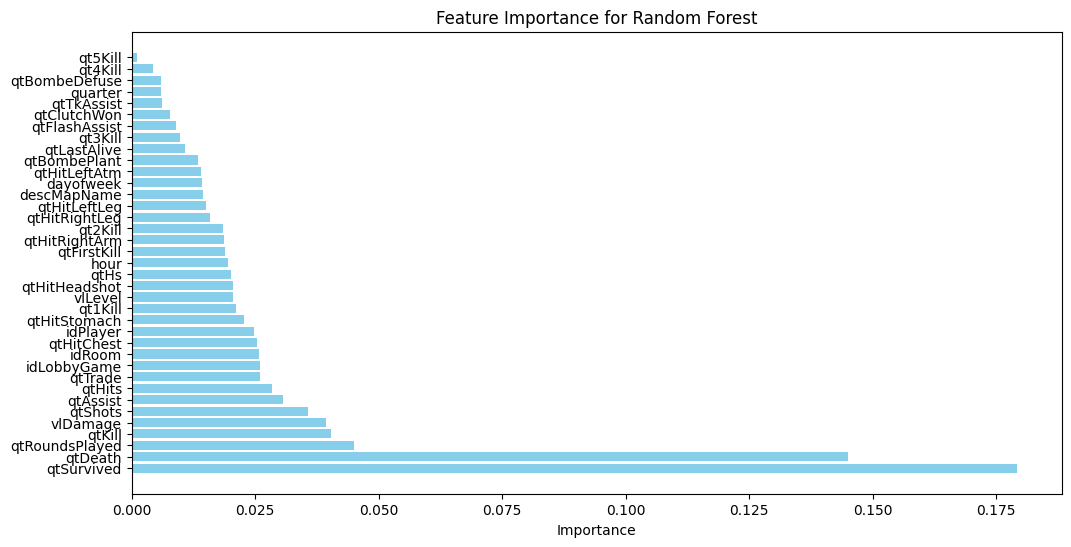

In [ ]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


print("Feature importances:")
print(feature_importance_df)
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance for Random Forest')
plt.show()